# Predictive Maintenance using Machine Learning

## AIM
To predict machine failures using machine learning algorithms and identify failure types for Predictive maintenance.

## Dataset
AI4I 2020 Predictive Maintenance Dataset

## Algorithms Used

- Logistic Regression
- Random Forest Classifier

## Libraries
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- ELI5



In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import eli5
from eli5.sklearn import PermutationImportance

plt.style.use("ggplot")


# 1. Load Dataset

In [2]:
# Load dataset
df = pd.read_csv("ai4i2020.csv")

# Display first five rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# 2. Data Exploration

In [3]:
# Dataset Information
df.info()

print("\nShape of Dataset:", df.shape)

print("\nMissing Values")
display(df.isnull().sum())

print("\nStatistical Summary")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


Statistical Summary


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
# Display all column names
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

# 3. Exploratory Data Analysis (EDA)

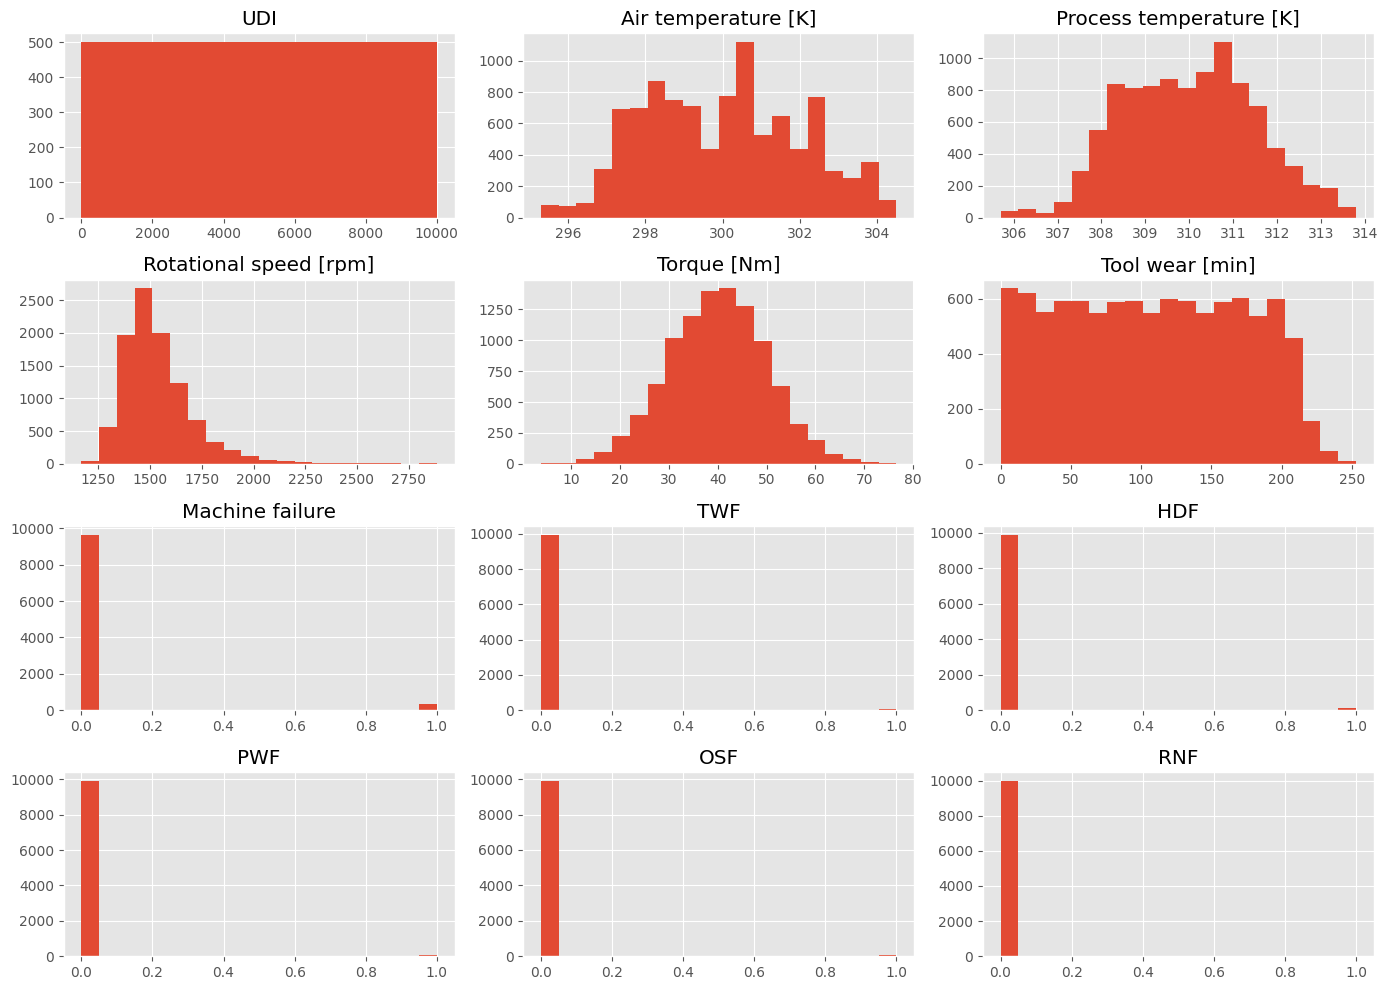

In [6]:
# Histogram of numerical features
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

Machine failure
0    9661
1     339
Name: count, dtype: int64


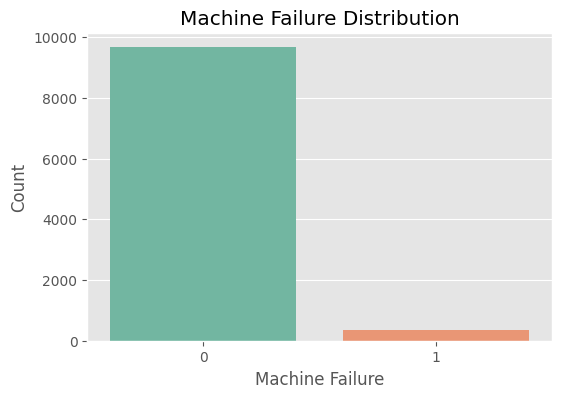

In [7]:
# Machine Failure Count
print(df["Machine failure"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x="Machine failure",
    data=df,
    palette="Set2"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

# 4. Failure Type Analysis

In [8]:
# Failure columns
failure_cols = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

# Function to classify failure
def classify_failure(row):
    for col in failure_cols:
        if row[col] == 1:
            return col
    return "No Failure"

# Create new column
df["Failure Type"] = df.apply(classify_failure, axis=1)

df[["Machine failure", "Failure Type"]].head()

,Machine failure,Failure Type
0,0,No Failure
1,0,No Failure
2,0,No Failure
3,0,No Failure
4,0,No Failure


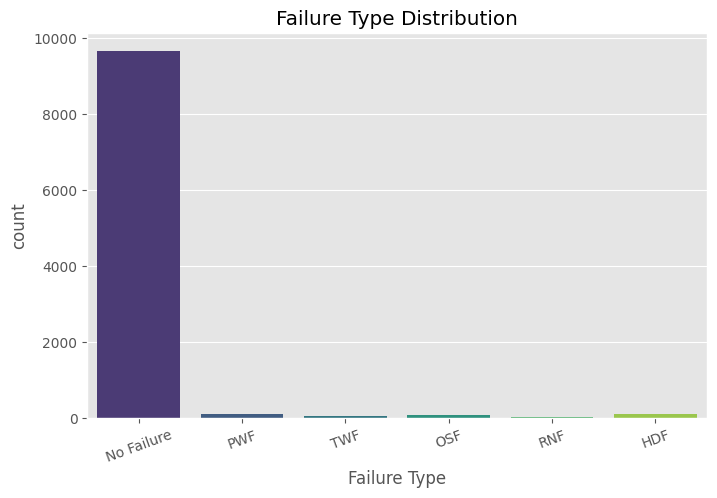

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Failure Type",
    data=df,
    palette="viridis"
)

plt.title("Failure Type Distribution")
plt.xticks(rotation=20)

plt.show()

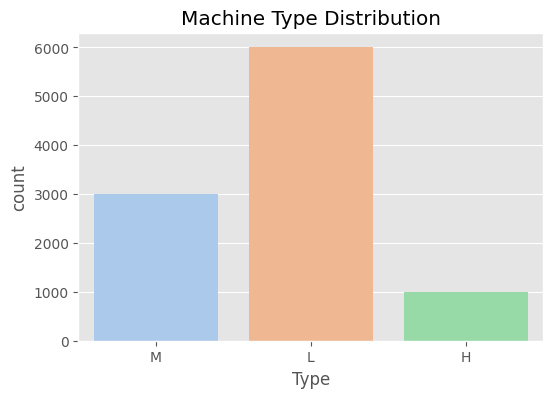

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Type",
    data=df,
    palette="pastel"
)

plt.title("Machine Type Distribution")

plt.show()

# 5. Relationship Between Sensor Variables

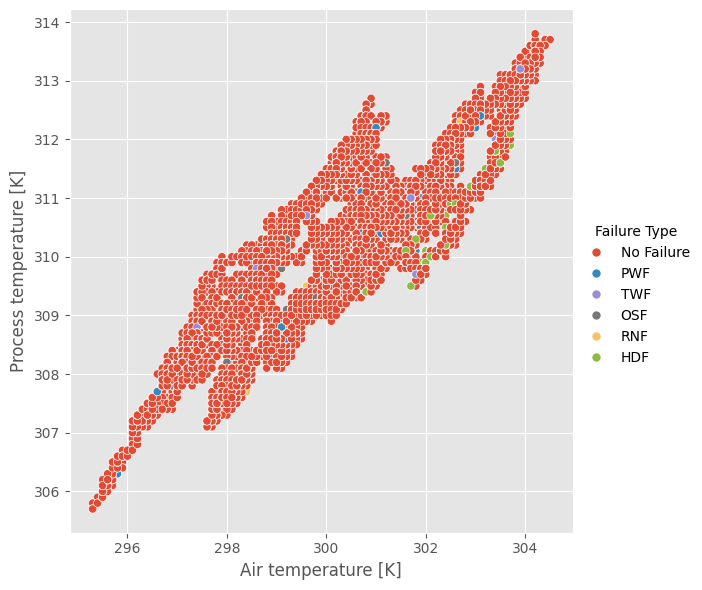

In [11]:
sns.relplot(
    data=df,
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Failure Type",
    height=6
)

plt.show()

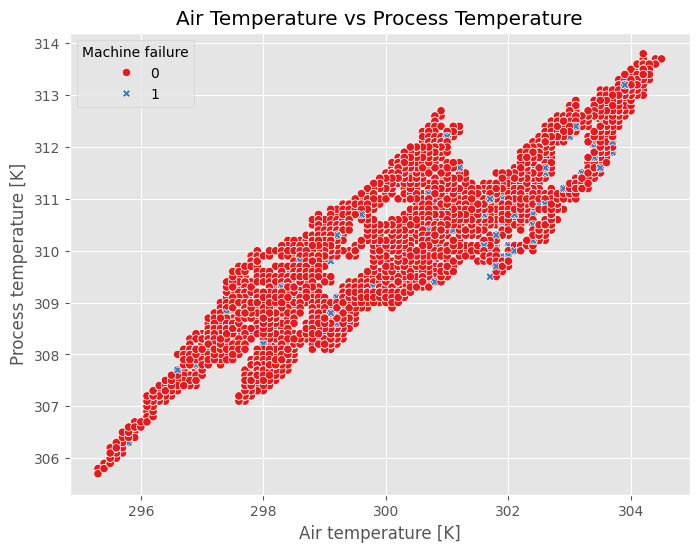

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Machine failure",
    style="Machine failure",
    palette="Set1",
    data=df
)

plt.title("Air Temperature vs Process Temperature")

plt.show()

# 6. Outlier Detection

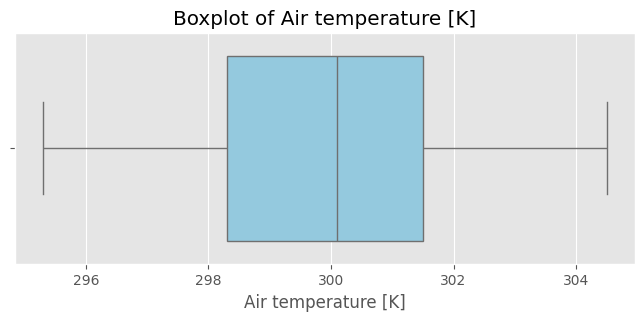

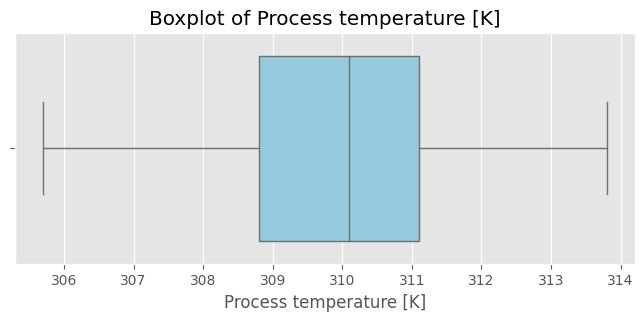

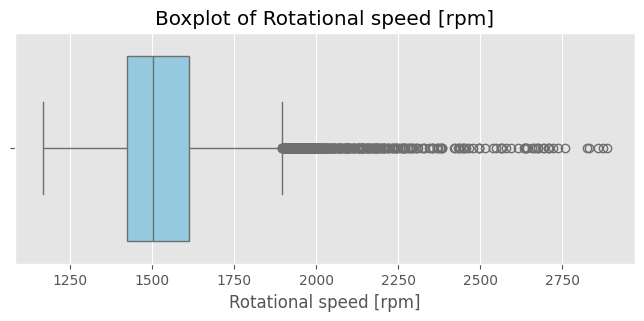

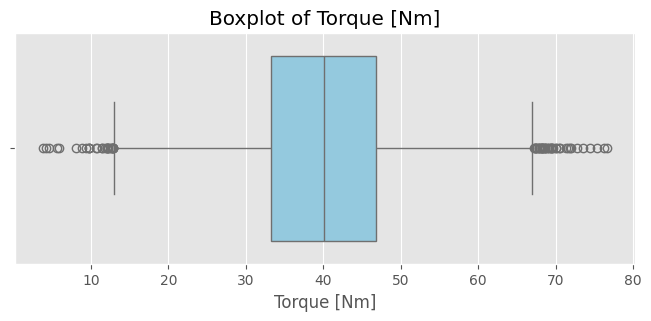

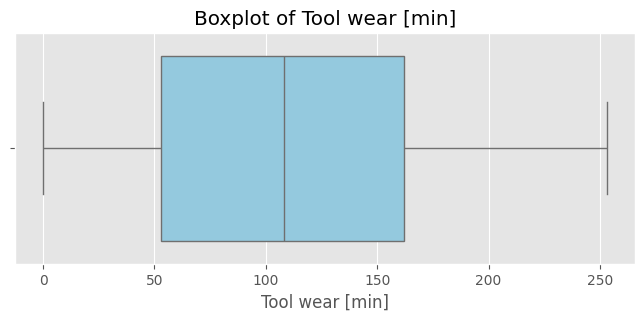

In [13]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for feature in sensor_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[feature],
        color="skyblue"
    )

    plt.title(f"Boxplot of {feature}")

    plt.show()

# 7. Feature Engineering

In [14]:
# Encode categorical values

df["Type"] = df["Type"].map({
    "L": 0,
    "M": 1,
    "H": 2
})

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Failure Type
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,No Failure
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,No Failure
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,No Failure
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,No Failure
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,No Failure


In [15]:
feature_cols = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[feature_cols]

y = df["Machine failure"]

# 8. Train-Test Split

In [16]:
# Target variable
y = df["Machine failure"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 7500
Testing Samples  : 2500


# 9. Build Machine Learning Models

In [17]:
def build_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model = build_model(rf_model, X_train, y_train)

In [19]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model = build_model(lr_model, X_train, y_train)

# 10. Model Evaluation

In [20]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9844


In [21]:
lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9684


In [22]:
print("Random Forest Classification Report\n")
print(classification_report(y_test, rf_pred))

print("\n")

print("Logistic Regression Classification Report\n")
print(classification_report(y_test, lr_pred))

Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2415
           1       0.90      0.61      0.73        85

    accuracy                           0.98      2500
   macro avg       0.94      0.80      0.86      2500
weighted avg       0.98      0.98      0.98      2500



Logistic Regression Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2415
           1       0.64      0.16      0.26        85

    accuracy                           0.97      2500
   macro avg       0.80      0.58      0.62      2500
weighted avg       0.96      0.97      0.96      2500



# 11. Confusion Matrix

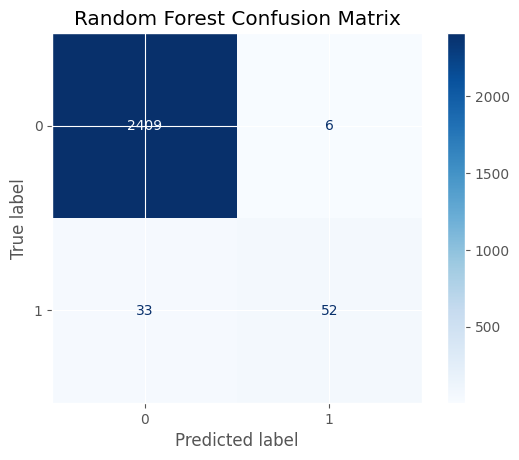

In [23]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

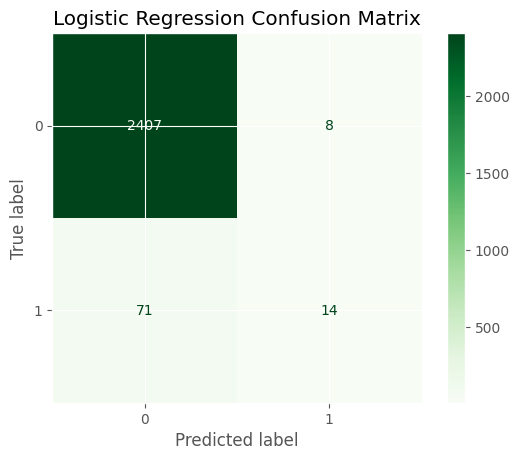

In [24]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(cmap="Greens")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# 12. Compare Model Accuracy

In [25]:
accuracy = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

accuracy

,Model,Accuracy
0,Random Forest,0.9844
1,Logistic Regression,0.9684


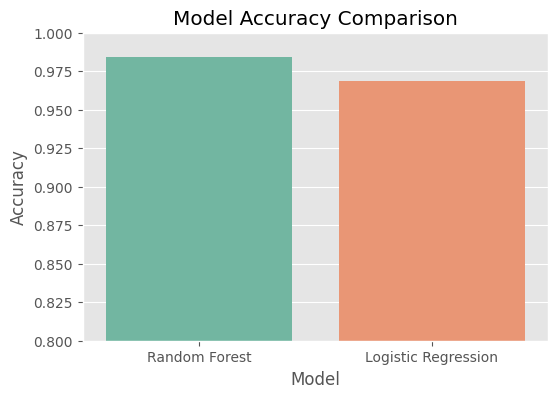

In [26]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=accuracy,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.ylim(0.8, 1.0)

plt.title("Model Accuracy Comparison")

plt.show()

# 13. Feature Importance (Random Forest)

In [27]:
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Torque [Nm],0.329852
3,Rotational speed [rpm],0.224161
5,Tool wear [min],0.168558
2,Process temperature [K],0.127817
1,Air temperature [K],0.121953
0,Type,0.027659


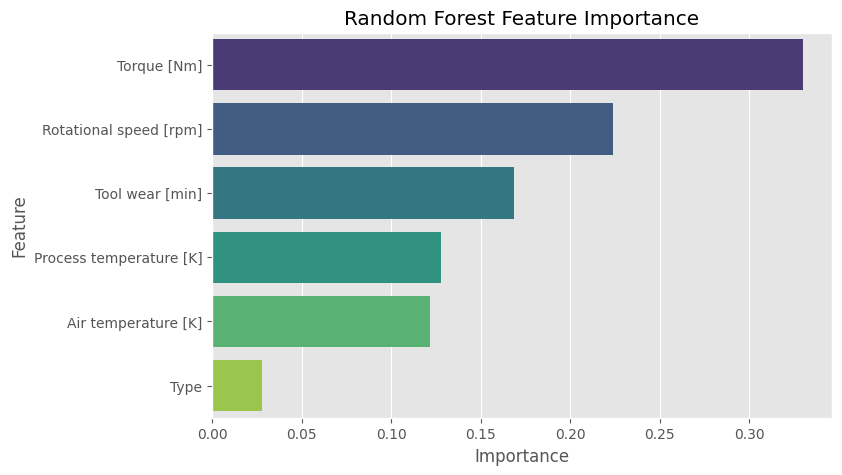

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Random Forest Feature Importance")

plt.show()

# 14. Model Interpretation using ELI5

In [29]:
eli5.show_weights(
    lr_model,
    feature_names=feature_cols
)

Weight?,Feature
+0.836,Air temperature [K]
+0.283,Torque [Nm]
+0.013,Tool wear [min]
+0.012,Rotational speed [rpm]
-0.010,<BIAS>
-0.406,Type
-0.923,Process temperature [K]


## Permutation Feature Importance
Permutation Importance shows how much each feature contributes to the prediction by measuring the decrease in model performance when that feature is randomly shuffled.

In [30]:
perm = PermutationImportance(
    lr_model,
    random_state=42
)

perm.fit(X_test, y_test)

eli5.show_weights(
    perm,
    feature_names=feature_cols
)

Weight,Feature
0.0784 ± 0.0045,Torque [Nm]
0.0551 ± 0.0055,Rotational speed [rpm]
0.0250 ± 0.0101,Air temperature [K]
0.0224 ± 0.0068,Process temperature [K]
0.0009 ± 0.0009,Tool wear [min]
-0.0009 ± 0.0019,Type


## Explain a Single Prediction

In [31]:
sample_data = X_test.iloc[0]

print("Actual Class :", y_test.iloc[0])

print("Random Forest Prediction :",
      rf_model.predict([sample_data])[0])

print("Logistic Regression Prediction :",
      lr_model.predict([sample_data])[0])

Actual Class : 0
Random Forest Prediction : 0
Logistic Regression Prediction : 0


In [32]:
eli5.show_prediction(
    lr_model,
    sample_data,
    feature_names=feature_cols
)

# 15. Preventive Maintenance (Failure Type Prediction)

Instead of predicting only whether the machine will fail, this model predicts the **type of failure**, allowing maintenance teams to take preventive actions before breakdown occurs.

In [33]:
# Features
X_multi = df[feature_cols]

# Target
y_multi = df["Failure Type"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.25,
    random_state=42,
    stratify=y_multi
)

In [35]:
rf_failure = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_failure.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
failure_pred = rf_failure.predict(X_test)

print("Accuracy :",
      accuracy_score(y_test, failure_pred))

print()

print(classification_report(
    y_test,
    failure_pred
))

Accuracy : 0.98

              precision    recall  f1-score   support

         HDF       0.85      0.76      0.80        29
  No Failure       0.98      1.00      0.99      2413
         OSF       0.79      0.58      0.67        19
         PWF       0.68      0.57      0.62        23
         RNF       0.00      0.00      0.00         4
         TWF       0.00      0.00      0.00        12

    accuracy                           0.98      2500
   macro avg       0.55      0.48      0.51      2500
weighted avg       0.97      0.98      0.98      2500



<Figure size 800x600 with 0 Axes>

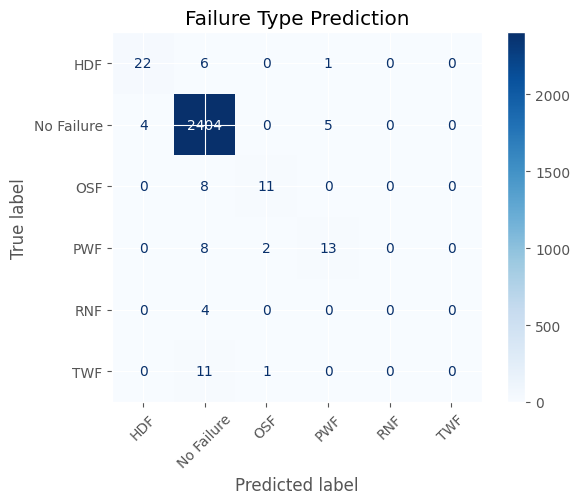

In [37]:
plt.figure(figsize=(8,6))

cm = confusion_matrix(
    y_test,
    failure_pred,
    labels=rf_failure.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_failure.classes_
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Failure Type Prediction")

plt.show()

# 16. Predict Maintenance Requirement for a New Machine

In [38]:
new_machine = pd.DataFrame({
    "Type":[1],
    "Air temperature [K]":[300.5],
    "Process temperature [K]":[310.2],
    "Rotational speed [rpm]":[1450],
    "Torque [Nm]":[42],
    "Tool wear [min]":[180]
})

prediction = rf_failure.predict(new_machine)[0]

print("Predicted Failure Type :", prediction)

Predicted Failure Type : No Failure


In [39]:
if prediction == "No Failure":
    print("Maintenance Status : Machine is Healthy.")
else:
    print(f"Maintenance Alert : Possible {prediction}.")
    print("Recommendation : Schedule Preventive Maintenance.")

Maintenance Status : Machine is Healthy.


# 17. Conclusion

### Random Forest
- Achieved high prediction accuracy.
- Performed better than Logistic Regression.
- Identified the most influential sensor parameters.

### Predictive Maintenance
- Predicted machine failure type.
- Helps engineers schedule maintenance before equipment failure.
- Reduces downtime and maintenance costs.
- Improves equipment reliability and production efficiency.

This project demonstrates how machine learning can support predictive and preventive maintenance in industrial systems.